   Year        T2M       RH2M  PRECTOTCORR District_Name      NDVI     Yield
0  2015  26.667507  44.516877       629.19       Lucknow  0.490388  2.368930
1  2016  26.608907  46.551257       869.86       Lucknow  0.382516  2.670001
2  2017  26.421589  48.908712       960.07       Lucknow  0.378340  2.580003
3  2018  26.099068  50.693671      1216.01       Lucknow  0.382765  2.730016
4  2019  25.414192  57.753973      1122.86       Lucknow  0.394574  2.661996

CLIMATE ANOMALY RESULTS
   District_Name  Year  Climate_Anomaly_Score Climate_Risk_Level
0        Lucknow  2015               3.719804          High Risk
1        Lucknow  2016               2.286731      Moderate Risk
2        Lucknow  2017               1.575014      Moderate Risk
3        Lucknow  2018               1.855208      Moderate Risk
4        Lucknow  2019               2.426381      Moderate Risk
5        Lucknow  2020               2.071550      Moderate Risk
6        Lucknow  2021               1.541360      Moderat

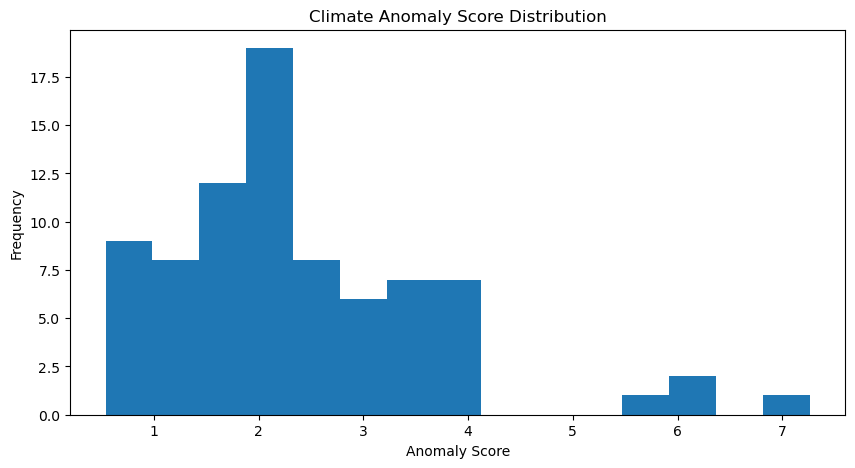


Climate anomaly dataset saved!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================
# LOAD DATASET
# =====================================

df = pd.read_csv(
    "../datasets/final_district_dataset.csv"
)

print(df.head())


# =====================================
# CALCULATE CLIMATE NORMALS
# =====================================

temp_mean = df['T2M'].mean()

temp_std = df['T2M'].std()

rain_mean = df['PRECTOTCORR'].mean()

rain_std = df['PRECTOTCORR'].std()

humidity_mean = df['RH2M'].mean()

humidity_std = df['RH2M'].std()


# =====================================
# ANOMALY SCORE FUNCTIONS
# =====================================

df['Temp_Anomaly'] = (
    (df['T2M'] - temp_mean)
    / temp_std
)

df['Rain_Anomaly'] = (
    (df['PRECTOTCORR'] - rain_mean)
    / rain_std
)

df['Humidity_Anomaly'] = (
    (df['RH2M'] - humidity_mean)
    / humidity_std
)


# =====================================
# COMBINED CLIMATE ANOMALY SCORE
# =====================================

df['Climate_Anomaly_Score'] = (
    abs(df['Temp_Anomaly']) +
    abs(df['Rain_Anomaly']) +
    abs(df['Humidity_Anomaly'])
)


# =====================================
# CLASSIFY CLIMATE RISK
# =====================================

def classify_risk(score):

    if score < 1.5:
        return "Normal"

    elif score < 3:
        return "Moderate Risk"

    else:
        return "High Risk"


df['Climate_Risk_Level'] = df[
    'Climate_Anomaly_Score'
].apply(classify_risk)


# =====================================
# RESULTS
# =====================================

print("\nCLIMATE ANOMALY RESULTS")

print(df[[
    'District_Name',
    'Year',
    'Climate_Anomaly_Score',
    'Climate_Risk_Level'
]].head(20))


# =====================================
# VISUALIZATION
# =====================================

plt.figure(figsize=(10,5))

plt.hist(
    df['Climate_Anomaly_Score'],
    bins=15
)

plt.title("Climate Anomaly Score Distribution")

plt.xlabel("Anomaly Score")

plt.ylabel("Frequency")

plt.show()


# =====================================
# SAVE DATASET
# =====================================

df.to_csv(
    "../datasets/climate_anomaly_dataset.csv",
    index=False
)

print("\nClimate anomaly dataset saved!")